# Speech emotion recognition with CNN from scratch

We train a **convolutional network built from scratch** (no pre-trained weights) to classify
the mel-spectrograms produced by `prepare_datasets.ipynb`
(folder `data/spectrograms/<emotion>/*.png`, Berlin EmoDB corpus).

The train/validation split is **by speaker** (the first 2 characters of the file name are
the speaker ID in EmoDB): otherwise the network recognises the voice and the score is
over-optimistic.

In [76]:
# deps (kernel "Python (CNN_RO11 .venv)")
# The default PyPI torch wheels are the CUDA build: they use the GPU when there is one and
# fall back to the CPU when there isn't. On a GPU-less machine we install the slim CPU
# wheels instead, to avoid downloading ~3 GB of CUDA libraries for nothing.
#
# `pip install torch` alone is not enough to switch build: if a torch is already there,
# whichever build it is, pip considers the requirement satisfied and does nothing. So we
# look at the build actually installed (the "+cu" / "+cpu" suffix) and reinstall only if
# it does not match the machine.
import importlib.metadata as md
import shutil

gpu = shutil.which("nvidia-smi") is not None
try:
    installed = md.version("torch")
except md.PackageNotFoundError:
    installed = None
print(f"NVIDIA GPU: {gpu}   torch installed: {installed}")

wanted_cuda = gpu
have_cuda = bool(installed) and "+cu" in installed

if installed is None or wanted_cuda != have_cuda:
    print("-> (re)installing the", "CUDA" if wanted_cuda else "CPU-only", "build of torch")
    if wanted_cuda:
        %pip install -q -U --force-reinstall torch torchvision
    else:
        %pip install -q -U --force-reinstall torch torchvision --index-url https://download.pytorch.org/whl/cpu
    print("!! RESTART THE KERNEL before running the next cell !!")
else:
    print("-> the installed build matches the machine, nothing to do")

%pip install -q scikit-learn matplotlib pillow

NVIDIA GPU: False   torch installed: 2.10.0
-> the installed build matches the machine, nothing to do
Note: you may need to restart the kernel to use updated packages.


In [77]:
from collections import Counter
from pathlib import Path

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# Reproducibility: make random operations deterministic
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA = Path("data/spectrograms")   # <emotion>/*.png produced by prepare_datasets.ipynb
IMG_SIZE = 128                     # spectrograms resized to 128 x 128
BATCH = 32
EPOCHS = 30
LR = 1e-3
VAL_SPEAKERS = {"15", "16"}        # 2 speakers out of 10 held out for validation
USE_SPECAUGMENT = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device)

torch 2.10.0 | device: cpu


### Image inventory and speaker split

We list every image, read its **emotion** (folder name) and its **speaker** (first 2
characters of the file name), then hold out the `VAL_SPEAKERS` for validation. A given
speaker is therefore **either** in training **or** in validation, never both — exactly as
in the transfer-learning notebook, so the results are comparable.

In [78]:
CLASSES = sorted(d.name for d in DATA.iterdir() if d.is_dir())   # emotion labels
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

# items: (image_path, class_index, speaker_id) for each png
items = [(p, CLASS_TO_IDX[p.parent.name], p.stem[:2]) for p in sorted(DATA.rglob("*.png"))]
speakers = sorted({s for _, _, s in items})

train_items = [it for it in items if it[2] not in VAL_SPEAKERS]
val_items   = [it for it in items if it[2] in VAL_SPEAKERS]

print("classes :", CLASSES)
print("speakers:", speakers)
print(f"train {len(train_items)} images / val {len(val_items)} images")
print("train distribution:", {CLASSES[i]: n for i, n in sorted(Counter(y for _, y, _ in train_items).items())})
print("val distribution  :", {CLASSES[i]: n for i, n in sorted(Counter(y for _, y, _ in val_items).items())})

classes : ['anger', 'boredom', 'disgust', 'fear', 'happiness', 'neutral', 'sadness']
speakers: ['03', '08', '09', '10', '11', '12', '13', '14', '15', '16']
train 408 images / val 127 images
train distribution: {'anger': 100, 'boredom': 58, 'disgust': 30, 'fear': 54, 'happiness': 54, 'neutral': 63, 'sadness': 49}
val distribution  : {'anger': 27, 'boredom': 23, 'disgust': 16, 'fear': 15, 'happiness': 17, 'neutral': 16, 'sadness': 13}


### Dataset and transforms

Each image is converted to grayscale, resized, turned into a tensor and
normalised around 0 (mean 0.5, std 0.5). Unlike transfer learning, **no ImageNet
normalisation** here: our network learns from scratch, it does not expect a particular
input distribution.

Augmentation (training only): `RandomErasing`, the SpecAugment equivalent — we mask a band
of time or frequency to make the network robust. **No horizontal flip**: reversing time is
not a plausible spectrogram.

In [79]:
train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.12), ratio=(0.3, 3.3)),
])

eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])


class SpectrogramDataset(Dataset):
    def __init__(self, items, tf):
        self.items, self.tf = items, tf

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        path, label, _ = self.items[i]
        return self.tf(Image.open(path)), label


train_loader = DataLoader(SpectrogramDataset(train_items, train_tf), batch_size=BATCH,
                          shuffle=True, num_workers=0, drop_last=False)
val_loader   = DataLoader(SpectrogramDataset(val_items, eval_tf), batch_size=BATCH,
                          shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print("batch:", tuple(xb.shape), "labels:", tuple(yb.shape))   # (B, 1, 128, 128)

batch: (32, 1, 128, 128) labels: (32,)


### CNN from scratch


Architecture required by the course (slide 17): **4 blocks**, each = two 3×3 convolutions
(+ BatchNorm + ReLU) followed by a 2×2 max-pool, with channels doubling at each block:
**1 → 32 → 64 → 128 → 256** (the leading 1 = our single-channel image). Then a *Global
Average Pooling* summarises each map into one value, a *dropout* limits overfitting, and a
final linear layer votes for the emotion.

The repeated pattern is factored into a `ConvBlock` class, reused 4 times.

In [80]:
class ConvBlock(nn.Module):
    '''Deux convolutions 3x3 -> BN + ReLU x2 -> MaxPool'''
    
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1) 
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.pool  = nn.MaxPool2d(2)                                      

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return self.pool(x)


class EmotionCNN(nn.Module):
    def __init__(self, n_classes, in_ch=1):
        super().__init__()
        self.block1 = ConvBlock(in_ch, 32)
        self.block2 = ConvBlock(32, 64)
        self.block3 = ConvBlock(64, 128)
        self.block4 = ConvBlock(128, 256)
        self.gap     = nn.AdaptiveAvgPool2d(1)   
        self.dropout = nn.Dropout(0.5)
        self.fc      = nn.Linear(256, n_classes) 

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)            
        x = torch.flatten(x, 1)    
        x = self.dropout(x)
        return self.fc(x)          


model = EmotionCNN(n_classes=len(CLASSES), in_ch=1).to(device)
total = sum(p.numel() for p in model.parameters())
print(f"trainable parameters : {total:,}")

# quick shape check
out = model(torch.randn(4, 1, IMG_SIZE, IMG_SIZE).to(device))
print("output :", tuple(out.shape), "(should be (4, %d))" % len(CLASSES))

trainable parameters : 1,175,399
output : (4, 7) (should be (4, 7))


In [81]:
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Nombre de paramètres entraînables : {n_params:,}")

dummy = torch.randn(4, 1, IMG_SIZE, IMG_SIZE).to(device)  # 4 fausses images
out = model(dummy)
print("Forme de la sortie :", out.shape, "(doit être [4, n_classes])")

Nombre de paramètres entraînables : 1,175,399
Forme de la sortie : torch.Size([4, 7]) (doit être [4, n_classes])


### Training loop
The dataset is imbalanced (more "anger" than "disgust"). The loss is weighted by the
inverse class frequency, otherwise the network mostly learns to predict the majority
class.

In [82]:
counts = np.bincount([y for _, y, _ in train_items], minlength=len(CLASSES))
class_weights = torch.tensor(counts.sum() / (len(CLASSES) * np.maximum(counts, 1)),
                             dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print({c: round(float(w), 2) for c, w in zip(CLASSES, class_weights)})


def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train(train)
    loss_sum, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            loss_sum += loss.item() * y.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            n        += y.size(0)
    return loss_sum / n, correct / n


def fit(model, optimizer, epochs, history, tag="scratch"):
    best_val, best_state = 0.0, None
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader)
        history.append({"phase": tag, "train_acc": tr_acc, "val_acc": va_acc,
                        "train_loss": tr_loss, "val_loss": va_loss})
        flag = ""
        if va_acc > best_val:
            best_val = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            flag = "  <-- best"
        print(f"[{tag}] epoch {epoch:2d}  train {tr_loss:.3f}/{tr_acc:.3f}   val {va_loss:.3f}/{va_acc:.3f}{flag}")
    if best_state is not None:
        model.load_state_dict(best_state)   # <-- restore the BEST-on-validation weights
        print(f"restored best validation accuracy: {best_val:.3f}")
    return history

{'anger': 0.58, 'boredom': 1.0, 'disgust': 1.94, 'fear': 1.08, 'happiness': 1.08, 'neutral': 0.93, 'sadness': 1.19}


### Training

In [83]:
history = []
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
fit(model, optimizer, EPOCHS, history)

torch.save({"state_dict": model.state_dict(), "classes": CLASSES,
            "img_size": IMG_SIZE, "in_channels": 1}, "cnn_scratch_emodb.pt")
print("weights saved to cnn_scratch_emodb.pt")

[scratch] epoch  1  train 1.630/0.370   val 3.988/0.118  <-- best
[scratch] epoch  2  train 1.165/0.534   val 5.051/0.134  <-- best
[scratch] epoch  3  train 0.979/0.625   val 2.910/0.157  <-- best
[scratch] epoch  4  train 0.912/0.657   val 2.749/0.189  <-- best
[scratch] epoch  5  train 0.826/0.674   val 2.242/0.370  <-- best
[scratch] epoch  6  train 0.763/0.738   val 2.462/0.370
[scratch] epoch  7  train 0.697/0.760   val 1.613/0.449  <-- best
[scratch] epoch  8  train 0.623/0.811   val 1.150/0.559  <-- best
[scratch] epoch  9  train 0.590/0.792   val 1.367/0.567  <-- best
[scratch] epoch 10  train 0.525/0.836   val 2.106/0.488
[scratch] epoch 11  train 0.456/0.853   val 1.810/0.504
[scratch] epoch 12  train 0.420/0.868   val 0.827/0.685  <-- best
[scratch] epoch 13  train 0.342/0.907   val 3.193/0.402
[scratch] epoch 14  train 0.310/0.914   val 2.317/0.433
[scratch] epoch 15  train 0.298/0.902   val 2.562/0.378
[scratch] epoch 16  train 0.260/0.931   val 3.504/0.346
[scratch] epoc

### Learning curves

If the *train* curve keeps rising while validation stalls,it is overfitting

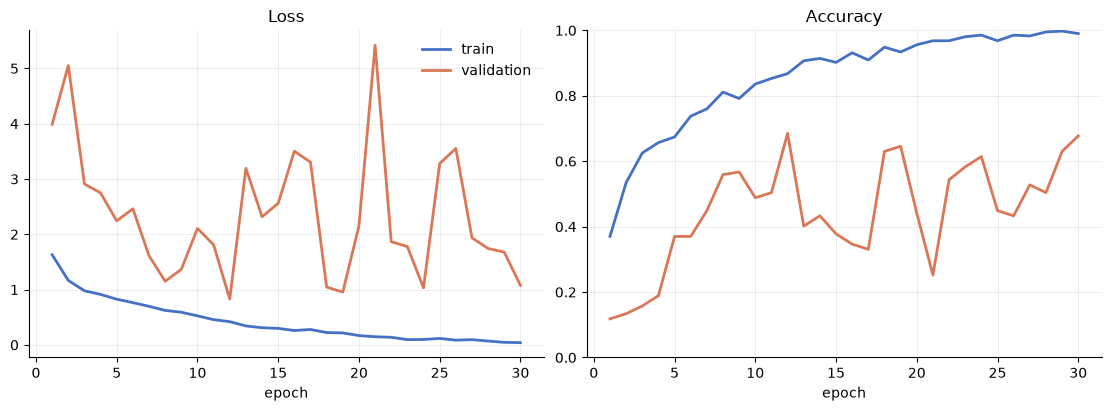

best validation accuracy : 0.685  (chance = 0.143)


In [86]:
import matplotlib.pyplot as plt

TRAIN_C, VAL_C = "#4571C4", "#D97757"
epochs = range(1, len(history) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, key, title in zip(axes, ["loss", "acc"], ["Loss", "Accuracy"]):
    ax.plot(epochs, [h[f"train_{key}"] for h in history], color=TRAIN_C, lw=2, label="train")
    ax.plot(epochs, [h[f"val_{key}"] for h in history], color=VAL_C, lw=2, label="validation")
    ax.set_title(title); ax.set_xlabel("epoch")
    ax.grid(alpha=0.25, lw=0.6); ax.spines[["top", "right"]].set_visible(False)
axes[1].set_ylim(0, 1)
axes[0].legend(frameon=False)
plt.show()

best = max(history, key=lambda h: h["val_acc"])
print(f"best validation accuracy : {best['val_acc']:.3f}  (chance = {1/len(CLASSES):.3f})")

### Evaluation: per-class report and confusion matrix


              precision    recall  f1-score   support

       anger       0.74      0.96      0.84        27
     boredom       0.84      0.70      0.76        23
     disgust       0.65      0.81      0.72        16
        fear       0.65      0.73      0.69        15
   happiness       1.00      0.12      0.21        17
     neutral       0.37      0.44      0.40        16
     sadness       0.80      0.92      0.86        13

    accuracy                           0.69       127
   macro avg       0.72      0.67      0.64       127
weighted avg       0.73      0.69      0.65       127

UAR (balanced accuracy) : 0.669


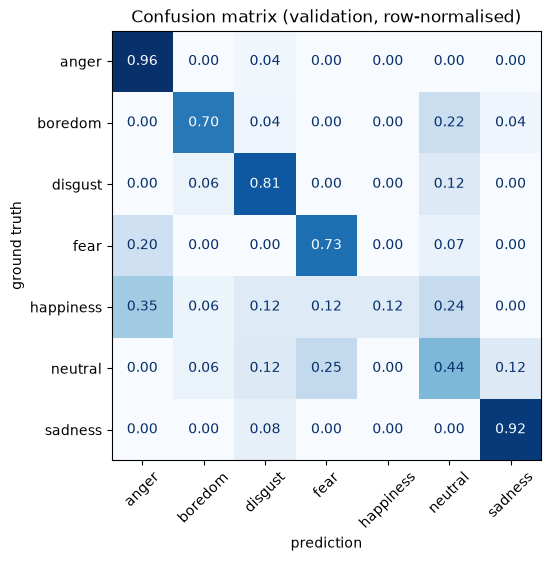

In [85]:
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             confusion_matrix, balanced_accuracy_score)

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in val_loader:
        y_pred += model(x.to(device)).argmax(1).cpu().tolist()
        y_true += y.tolist()

print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0))
print(f"UAR (balanced accuracy) : {balanced_accuracy_score(y_true, y_pred):.3f}")

cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASSES)), normalize="true")
fig, ax = plt.subplots(figsize=(6.5, 5.5), constrained_layout=True)
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format=".2f", xticks_rotation=45)
ax.set_title("Confusion matrix (validation, row-normalised)")
ax.set_xlabel("prediction"); ax.set_ylabel("ground truth"); ax.grid(False)
plt.show()